# A2-02: Image Segmentation with U-Net

Having covered object detection (bounding boxes), we now move to **image segmentation** — assigning a class label to *every pixel* in the image.

We will build **U-Net** from scratch and train it on the Oxford-IIIT Pet dataset.


## Types of Image Segmentation

Object detection gives us bounding boxes — but what if we need to know exactly *which pixels* belong to each object? That's where segmentation comes in.

There are two fundamentally different segmentation tasks:

| | Semantic Segmentation | Instance Segmentation |
|---|---|---|
| **Question** | What class is each pixel? | Which *individual object* does each pixel belong to? |
| **Output** | Class label per pixel | Object ID + class per pixel |
| **Same-class objects** | Merged together | Separated |
| **Typical model** | U-Net, FCN, DeepLab | Mask R-CNN |

<img src="img/segmentation_types.png" title="Semantic vs Instance Segmentation" style="width: 900px;" />


### Visual comparison

```
Original image: 🐱 🐱 🐶

Semantic segmentation:
  [cat][cat][cat][cat][dog][dog]   ← all cats same color, dog different
   ████████████████  ████████
   cat (label=1)     dog (label=2)

Instance segmentation:
  [cat#1][cat#1][cat#2][cat#2][dog#1]
   ██████  ██████  ████████
   cat id=1  cat id=2  dog id=1
```

**Key insight**: Semantic segmentation cannot distinguish between two cats sitting side by side. Instance segmentation can.

## Semantic Segmentation: FCN and U-Net

### Fully Convolutional Network (FCN, 2015)

The first major deep learning approach to semantic segmentation. The key idea: replace the final FC layers of a classification CNN with **1×1 convolutions**, then **upsample** back to input resolution.

```
Classification CNN:   Conv → Pool → ... → FC → softmax
FCN:                  Conv → Pool → ... → 1×1 Conv → Upsample → pixel labels
```

Problem: upsampling from a very small feature map loses spatial detail — edges and fine boundaries get blurry.

### U-Net (2015)

U-Net solved the spatial detail problem with **skip connections** — direct paths from encoder to decoder.

<img src="img/unet_arch.png" title="U-Net Architecture" style="width: 800px;" />

**Reading the diagram:**

- **Left side (encoder / contracting path)** — standard CNN: DoubleConv blocks (blue arrows) shrink spatial size and double channels at each level via MaxPool (red arrow). Four stages: 64 → 128 → 256 → 512 channels.
- **Bottom (bottleneck)** — deepest representation: 1024 channels at the smallest spatial size. No skip connection here — purely compressed features.
- **Right side (decoder / expanding path)** — up-conv 2×2 (green arrow) doubles spatial size and halves channels at each level. Then concatenate the **skip connection** from the matching encoder stage (gray arrow = "copy and crop"), then DoubleConv to process the merged features.
- **Gray arrows (copy and crop)** — this is the skip connection. The encoder's high-resolution feature map is copied directly to the decoder at the same depth level. "Crop" because the original U-Net had no padding — feature maps shrink slightly through each conv, so the encoder map is center-cropped to match the decoder size. In modern implementations (with `padding=1`) the sizes match exactly — no cropping needed.
- **Top right (output)** — final Conv 1×1 (teal arrow) maps from 64 channels to the number of classes (2 in the original paper for binary segmentation).

**Why do skip connections matter?**

> "Classification only needs to know *what*. Segmentation needs to know *what* AND *exactly where*. Deep features = what. Shallow features = where. Skip connections bring both to the decoder simultaneously."

Without skip connections the decoder must reconstruct spatial detail from the bottleneck alone — like drawing a precise boundary from a blurry thumbnail. With skip connections the decoder has the encoder's full-resolution edge maps to guide it.

### Loss and Metrics

**Per-pixel Cross-Entropy Loss**:
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log(\hat{p}_{ic})$$

**mean IoU (mIoU)** — standard metric for segmentation:
$$\text{mIoU} = \frac{1}{C} \sum_{c=1}^{C} \frac{TP_c}{TP_c + FP_c + FN_c}$$

where $TP_c$ = pixels correctly predicted as class $c$, $FP_c$ = pixels wrongly predicted as $c$, $FN_c$ = pixels of class $c$ missed.


## Instance Segmentation: Mask R-CNN (2017)

**Paper:** He et al., *Mask R-CNN*, ICCV 2017

Mask R-CNN extends Faster R-CNN by adding a third output head: a **pixel-level mask** for each detected instance.

### Architecture

<img src="img/maskrcnn_arch.png" title="Mask R-CNN Architecture" style="width: 700px;" />

```
Input Image
    ↓
CNN Backbone (ResNet-50 + FPN)
    ↓
RPN → Region Proposals
    ↓
RoI Align  ← key improvement over RoI Pooling
    ├── Classification head  → class label
    ├── Bounding box head    → refined (x, y, w, h)
    └── Mask head            → 28×28 binary mask (per class)
```

### RoI Align vs RoI Pooling

<img src="img/maskrcnn_roialign.png" title="RoI Align" style="width: 350px;" />

RoI Pooling **quantizes** proposal coordinates to integer pixels before pooling — introduces misalignment that degrades mask quality.

RoI Align uses **bilinear interpolation** to sample at exact (non-integer) positions:

```
RoI Pooling:  proposal (10.7, 20.3) → snapped to (10, 20) → pool
RoI Align:    proposal (10.7, 20.3) → bilinear interp at (10.7, 20.3) → pool
```

The dots in the diagram are the sampling points inside each 2×2 bin — each sampled by bilinear interpolation from the 4 surrounding feature map cells (dashed grid). No rounding.

### Mask Head

A small FCN applied independently to each RoI:
4 conv layers → predict a $K \times 28 \times 28$ mask (one binary mask per class $K$).
At inference, only the mask for the **predicted class** is used — classes don't compete.

### Loss

$$\mathcal{L} = \mathcal{L}_{\text{cls}} + \mathcal{L}_{\text{box}} + \mathcal{L}_{\text{mask}}$$

$\mathcal{L}_{\text{mask}}$ = binary cross-entropy applied **only to the GT class mask** per instance.

### Results from the paper

<img src="img/maskrcnn_results.png" title="Mask R-CNN Results" style="width: 700px;" />

### When to use which?

| Scenario | Best choice |
|---|---|
| Classify every pixel (road, sky, building) | Semantic — U-Net / DeepLab |
| Count/separate individual objects | Instance — Mask R-CNN |
| Both: per-pixel labels AND separate instances | Panoptic segmentation |

---


Detected 3 objects (score ≥ 0.7):
  [0] bicycle         score=0.993
  [1] horse           score=0.992
  [2] truck           score=0.794


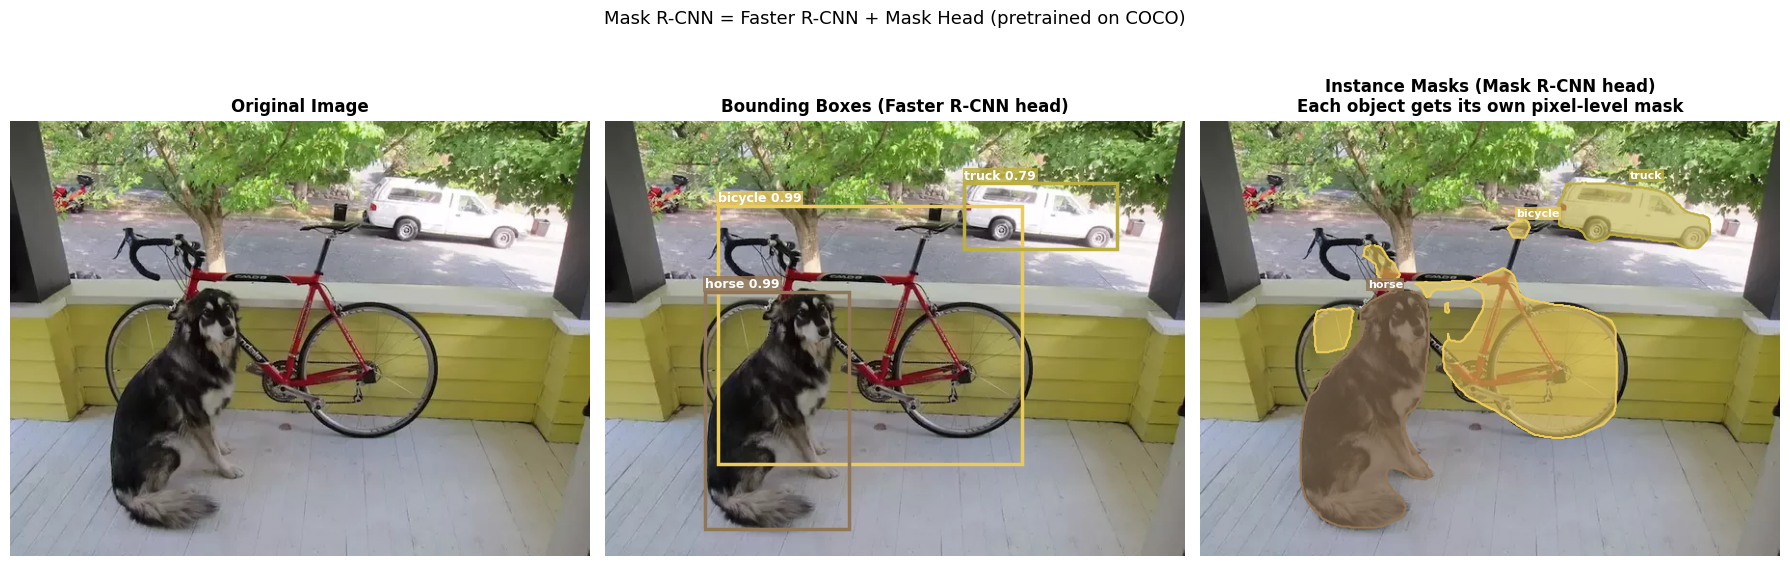

In [4]:
# ── Mask R-CNN: pretrained on COCO, run on dog-cycle-car image ────────────────
import torch
import torchvision
import torchvision.transforms.functional as TF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load pretrained Mask R-CNN (ResNet-50 + FPN backbone, trained on COCO 91 classes)
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
model.eval().to(device)

# COCO class names
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane',
    'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
    'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
    'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# Color palette for masks
np.random.seed(42)
COLORS = np.random.randint(0, 255, size=(len(COCO_CLASSES), 3), dtype=np.uint8)

# ── Load and preprocess image ─────────────────────────────────────────────────
img_bgr = cv2.imread('dog-cycle-car.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# torchvision Mask R-CNN expects a float tensor [0,1]
img_t = TF.to_tensor(img_rgb).to(device)   # (3, H, W)

# ── Run inference ─────────────────────────────────────────────────────────────
with torch.no_grad():
    outputs = model([img_t])

output    = outputs[0]
boxes     = output['boxes'].cpu().numpy()
labels    = output['labels'].cpu().numpy()
scores    = output['scores'].cpu().numpy()
masks     = output['masks'].cpu().numpy()   # (N, 1, H, W) — soft masks [0,1]

# Keep only high-confidence detections
THRESHOLD = 0.7
keep   = scores >= THRESHOLD
boxes  = boxes[keep];  labels = labels[keep]
scores = scores[keep]; masks  = masks[keep]

print(f"Detected {keep.sum()} objects (score ≥ {THRESHOLD}):")
for i, (label, score) in enumerate(zip(labels, scores)):
    print(f"  [{i}] {COCO_CLASSES[label]:<15} score={score:.3f}")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: original image
axes[0].imshow(img_rgb)
axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Panel 2: bounding boxes + labels (Faster R-CNN part)
axes[1].imshow(img_rgb)
for box, label, score in zip(boxes, labels, scores):
    x1, y1, x2, y2 = box
    color = tuple(COLORS[label] / 255.)
    rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=2.5, edgecolor=color, facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(x1, y1 - 4, f"{COCO_CLASSES[label]} {score:.2f}",
                 color='white', fontsize=9, fontweight='bold',
                 bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))
axes[1].set_title('Bounding Boxes (Faster R-CNN head)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Panel 3: instance masks overlaid
overlay = img_rgb.copy().astype(np.float32)
for mask, label in zip(masks, labels):
    binary_mask = (mask[0] > 0.5)                 # threshold soft mask → binary
    color       = COLORS[label].astype(np.float32)
    overlay[binary_mask] = overlay[binary_mask] * 0.4 + color * 0.6

axes[2].imshow(overlay.astype(np.uint8))
# Draw contours for each mask
for mask, label, score in zip(masks, labels, scores):
    binary = (mask[0] > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        cnt_pts = cnt.squeeze()
        if cnt_pts.ndim == 2:
            axes[2].plot(cnt_pts[:,0], cnt_pts[:,1],
                        color=tuple(COLORS[label]/255.), linewidth=1.5)
    # label at top of mask
    ys, xs = np.where(binary)
    if len(ys):
        axes[2].text(xs.mean(), ys.min() - 4, COCO_CLASSES[label],
                    color='white', fontsize=8, fontweight='bold',
                    bbox=dict(facecolor=tuple(COLORS[label]/255.), alpha=0.8, pad=1, edgecolor='none'))
axes[2].set_title('Instance Masks (Mask R-CNN head)\nEach object gets its own pixel-level mask',
                  fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle('Mask R-CNN = Faster R-CNN + Mask Head (pretrained on COCO)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Dataset: Oxford-IIIT Pet Dataset

**Oxford-IIIT Pet** (Parkhi et al., 2012) — 37 breeds of cats and dogs with pixel-level masks:
- **Class 1**: Pet (foreground)
- **Class 2**: Background
- **Class 3**: Border/uncertain region

**Reference:** Parkhi et al. (2012). *Cats and Dogs*. CVPR.
Dataset: https://www.robots.ox.ac.uk/~vgg/data/pets/

---

100%|██████████| 792M/792M [02:47<00:00, 4.72MB/s]  
100%|██████████| 19.2M/19.2M [00:07<00:00, 2.62MB/s]


Train: 3680 | Test: 3669


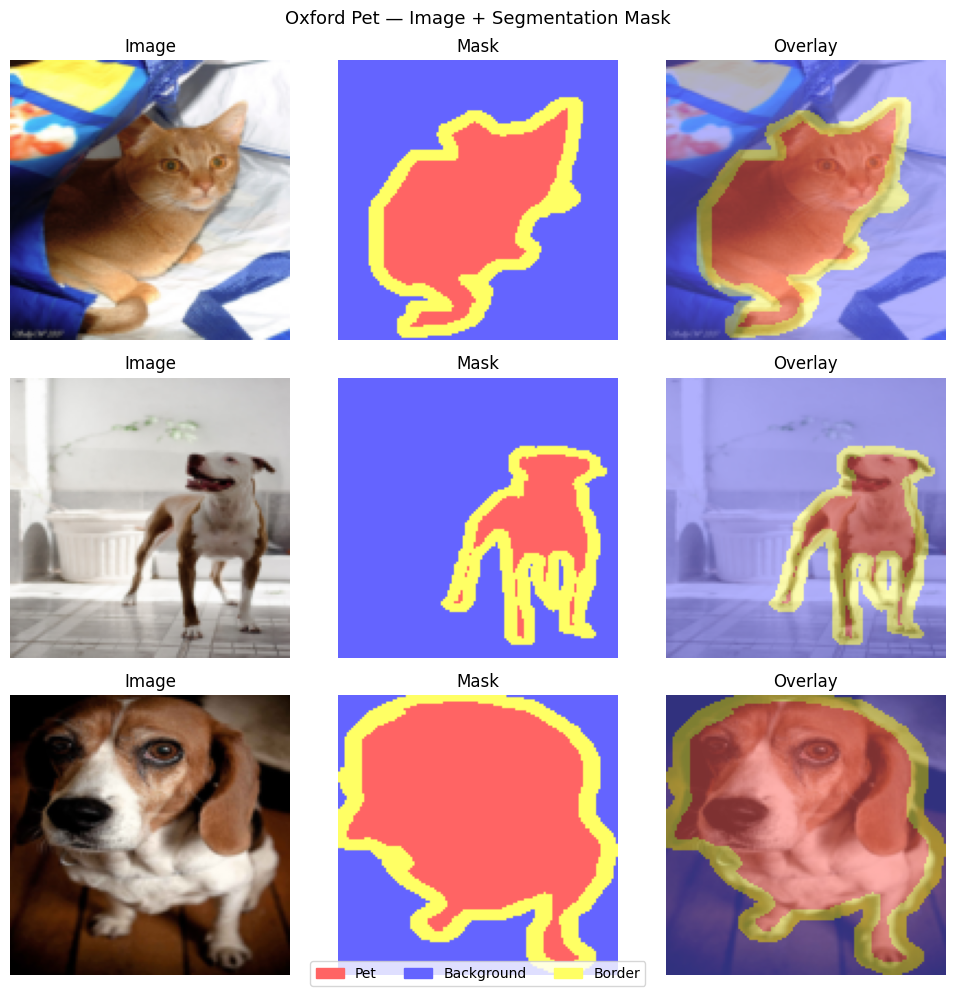

In [6]:
from torchvision.datasets import OxfordIIITPet

os.makedirs('./data', exist_ok=True)
IMG_SIZE = 128

train_raw = OxfordIIITPet('./data', split='trainval', target_types='segmentation', download=True)
test_raw  = OxfordIIITPet('./data', split='test',     target_types='segmentation', download=True)
print(f'Train: {len(train_raw)} | Test: {len(test_raw)}')

class PetSegDataset(Dataset):
    def __init__(self, base, size=128):
        self.ds = base
        self.img_tf  = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.PILToTensor(),
        ])
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        img, mask = self.ds[idx]
        img  = self.img_tf(img)
        mask = (self.mask_tf(mask).squeeze(0).long() - 1).clamp(0, 2)
        return img, mask

train_data   = PetSegDataset(train_raw, IMG_SIZE)
test_data    = PetSegDataset(test_raw,  IMG_SIZE)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=16, shuffle=False, num_workers=2)

# Visualize samples
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
CLASS_COLORS = np.array([[255,100,100],[100,100,255],[255,255,100]], dtype=np.uint8)
CLASS_NAMES  = ['Pet', 'Background', 'Border']

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img, mask = train_data[i*100]
    img_d  = torch.clamp(img * std + mean, 0, 1).permute(1,2,0).numpy()
    mask_d = CLASS_COLORS[mask.numpy()]
    axes[i][0].imshow(img_d);  axes[i][0].set_title('Image');   axes[i][0].axis('off')
    axes[i][1].imshow(mask_d); axes[i][1].set_title('Mask');    axes[i][1].axis('off')
    axes[i][2].imshow(img_d);  axes[i][2].imshow(mask_d, alpha=0.5)
    axes[i][2].set_title('Overlay'); axes[i][2].axis('off')
patches = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(patches, CLASS_NAMES, loc='lower center', ncol=3)
plt.suptitle('Oxford Pet — Image + Segmentation Mask', fontsize=13)
plt.tight_layout(); plt.show()

## Building U-Net from Scratch

The key building block is **DoubleConv**: Conv → BN → ReLU → Conv → BN → ReLU

---

In [7]:
class DoubleConv(nn.Module):
    """Two consecutive Conv2d -> BN -> ReLU blocks. The core building block of U-Net."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),  # same-padding keeps spatial size
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=3, features=[64, 128, 256, 512]):
        super().__init__()

        # ── Encoder (contracting path) ────────────────────────────────────────
        # Each stage: DoubleConv doubles channels, MaxPool halves spatial size
        # features = [64, 128, 256, 512]  →  4 encoder stages
        self.encoders = nn.ModuleList()
        self.pools    = nn.ModuleList()
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))   # e.g. 3→64, 64→128, ...
            self.pools.append(nn.MaxPool2d(2))         # /2 spatial size
            ch = f

        # ── Bottleneck ────────────────────────────────────────────────────────
        # Deepest point: highest channels (512→1024), smallest spatial size
        # No skip connection here — pure semantic compression
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)  # 512→1024

        # ── Decoder (expanding path) ──────────────────────────────────────────
        # Each stage: up-conv doubles spatial size, then concat skip, then DoubleConv
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2   # start from bottleneck output (1024)
        for f in reversed(features):   # 512, 256, 128, 64
            self.upconvs.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)  # 2x upsample
            )
            self.decoders.append(
                DoubleConv(f * 2, f)   # f*2 because we concat skip (f) + upconv output (f)
            )
            ch = f

        # ── Output head ───────────────────────────────────────────────────────
        # 1x1 conv maps final feature map to per-pixel class scores
        self.output = nn.Conv2d(features[0], n_classes, kernel_size=1)  # 64→n_classes

    def forward(self, x):
        # ── Encoder: save skip connections at each stage ──────────────────────
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)          # DoubleConv: extract features at this resolution
            skips.append(x)     # save for skip connection to the matching decoder stage
            x = pool(x)         # halve spatial size before next stage

        # ── Bottleneck ────────────────────────────────────────────────────────
        x = self.bottleneck(x)

        # ── Decoder: upsample + skip connection + DoubleConv ─────────────────
        for upconv, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = upconv(x)       # 2x upsample (ConvTranspose2d)

            # Handle size mismatch due to odd input dimensions
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:])

            # Skip connection: concat encoder features with decoder features
            # skip carries fine spatial detail (edges, boundaries) from the encoder
            # x    carries semantic context (what object) from the bottleneck
            x = torch.cat([skip, x], dim=1)   # channels: f + f = f*2

            x = dec(x)          # DoubleConv: fuse skip + upsampled features

        # ── Output ────────────────────────────────────────────────────────────
        return self.output(x)   # (N, n_classes, H, W) — same spatial size as input


model = UNet().to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
out   = model(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}  <- same H x W as input')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])  <- same H x W as input
Params: 31,037,763


## U-Net with Pretrained ResNet-18 Encoder

Instead of training the encoder from scratch, we replace it with **ResNet-18 pretrained on ImageNet**.

The encoder stages map directly to ResNet-18 layers:

| U-Net Stage | ResNet-18 layer | Output channels | Spatial size (for 128×128 input) |
|---|---|---|---|
| Stage 1 | `layer1` | 64 | 32×32 |
| Stage 2 | `layer2` | 128 | 16×16 |
| Stage 3 | `layer3` | 256 | 8×8 |
| Stage 4 | `layer4` | 512 | 4×4 |

The decoder is the same as the scratch U-Net — up-conv + skip connection + DoubleConv at each stage.

**Why does this help?**
ResNet-18 was trained to classify 1,000 ImageNet categories — its early layers already detect edges, textures, and shapes. Fine-tuning on Oxford Pet takes far fewer epochs to converge than training from scratch.


In [8]:
import torchvision.models as models

class UNetResNet18(nn.Module):
    """U-Net with pretrained ResNet-18 encoder. Decoder restores full input resolution.
    
    ResNet-18 on 128x128 input:
      stem_conv (stride=2) → 64x64   [s0, skip]
      stem_pool (stride=2) → 32x32
      layer1               → 32x32   [s1, skip]
      layer2 (stride=2)    → 16x16   [s2, skip]
      layer3 (stride=2)    → 8x8     [s3, skip]
      layer4 (stride=2)    → 4x4     [s4, skip]
    Decoder: 4→8→16→32→64→128 (5 upsamples)
    """

    def __init__(self, n_classes=3, pretrained=True):
        super().__init__()

        weights = 'IMAGENET1K_V1' if pretrained else None
        resnet  = models.resnet18(weights=weights)

        # Stem split into 2 parts to get skip at H/2
        self.stem_conv = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # →H/2, 64ch
        self.stem_pool = resnet.maxpool                                          # →H/4

        self.enc1 = resnet.layer1   # →H/4,  64ch  (no downsample in layer1)
        self.enc2 = resnet.layer2   # →H/8,  128ch
        self.enc3 = resnet.layer3   # →H/16, 256ch
        self.enc4 = resnet.layer4   # →H/32, 512ch

        self.bottleneck = DoubleConv(512, 1024)

        # Decoder: 5 upsamples to go from H/32 back to H
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(512 + 512, 512)   # H/32 → H/16, concat s4

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(256 + 256, 256)   # H/16 → H/8,  concat s3

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(128 + 128, 128)   # H/8  → H/4,  concat s2

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(64 + 64, 64)      # H/4  → H/2,  concat s1

        self.up0  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec0 = DoubleConv(32 + 64, 32)      # H/2  → H,    concat s0 (stem_conv)

        self.output = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        s0 = self.stem_conv(x)   # H/2, 64ch  ← skip for dec0
        sp = self.stem_pool(s0)  # H/4
        s1 = self.enc1(sp)       # H/4, 64ch  ← skip for dec1
        s2 = self.enc2(s1)       # H/8, 128ch ← skip for dec2
        s3 = self.enc3(s2)       # H/16,256ch ← skip for dec3
        s4 = self.enc4(s3)       # H/32,512ch ← skip for dec4

        x = self.bottleneck(s4)  # H/32, 1024ch

        x = self.up4(x);  x = self._cat(x, s4);  x = self.dec4(x)  # H/16
        x = self.up3(x);  x = self._cat(x, s3);  x = self.dec3(x)  # H/8
        x = self.up2(x);  x = self._cat(x, s2);  x = self.dec2(x)  # H/4
        x = self.up1(x);  x = self._cat(x, s1);  x = self.dec1(x)  # H/2
        x = self.up0(x);  x = self._cat(x, s0);  x = self.dec0(x)  # H

        return self.output(x)   # (N, n_classes, H, W)

    def _cat(self, x, skip):
        # x is the upsampled decoder feature — always larger or equal
        # skip may be slightly smaller due to odd dimensions → upsample skip to match x
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:])
        return torch.cat([skip, x], dim=1)


# Sanity check
resnet_model = UNetResNet18(n_classes=3, pretrained=True).to(device)
dummy = torch.randn(2, 3, 128, 128).to(device)
out   = resnet_model(dummy)
print(f'Input:  {dummy.shape}')
print(f'Output: {out.shape}')
assert out.shape[-2:] == dummy.shape[-2:], f"Size mismatch! {out.shape} vs {dummy.shape}"
print(f'Output size matches input — OK')
print(f'Params: {sum(p.numel() for p in resnet_model.parameters()):,}')


Input:  torch.Size([2, 3, 128, 128])
Output: torch.Size([2, 3, 128, 128])
Output size matches input — OK
Params: 37,572,099


## Training U-Net

Loss: **Cross-Entropy** per pixel

Metric: **mIoU** (mean Intersection over Union) — standard segmentation benchmark

$$\text{IoU} = \frac{\text{Predicted} \cap \text{Ground Truth}}{\text{Predicted} \cup \text{Ground Truth}}$$

---

In [9]:
# ── Choose which model to train ───────────────────────────────────────────────
# 'scratch'   → UNet built from random init (custom Conv encoder)
# 'resnet18'  → UNet with pretrained ResNet-18 encoder (ImageNet)
MODEL_TYPE = 'resnet18'   # change to 'scratch' to train from scratch

if MODEL_TYPE == 'scratch':
    model = UNet(n_classes=3).to(device)
    print("Training U-Net from scratch")
else:
    model = UNetResNet18(n_classes=3, pretrained=True).to(device)
    print("Training U-Net with pretrained ResNet-18 encoder")

from tqdm import tqdm

def compute_iou(pred, target, n_classes=3):
    pred = pred.argmax(dim=1)
    ious = []
    for cls in range(n_classes):
        inter = ((pred==cls) & (target==cls)).sum().float()
        union = ((pred==cls) | (target==cls)).sum().float()
        if union > 0: ious.append((inter/union).item())
    return np.mean(ious) if ious else 0.0

Training U-Net with pretrained ResNet-18 encoder


In [10]:
EPOCHS    = 20
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

save_name = f'unet_{MODEL_TYPE}_pet.pt'

train_losses, val_ious = [], []
for epoch in range(EPOCHS):
    model.train()
    ep_loss = []
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        imgs, masks = imgs.to(device), masks.to(device)
        loss = criterion(model(imgs), masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep_loss.append(loss.item())
    model.eval()
    ep_iou = []
    with torch.no_grad():
        for imgs, masks in test_loader:
            ep_iou.append(compute_iou(model(imgs.to(device)), masks.to(device)))
    scheduler.step()
    train_losses.append(np.mean(ep_loss))
    val_ious.append(np.mean(ep_iou))
    print(f'Epoch {epoch+1:02d} | Loss: {train_losses[-1]:.4f} | mIoU: {val_ious[-1]:.4f}')

torch.save(model.state_dict(), save_name)
print(f'Saved → {save_name}')

Epoch 1/20: 100%|██████████| 230/230 [00:11<00:00, 19.23it/s]


Epoch 01 | Loss: 0.4181 | mIoU: 0.7088


Epoch 2/20: 100%|██████████| 230/230 [00:12<00:00, 18.94it/s]


Epoch 02 | Loss: 0.2918 | mIoU: 0.6920


Epoch 3/20: 100%|██████████| 230/230 [00:12<00:00, 18.73it/s]


...

Epoch 18 | Loss: 0.1027 | mIoU: 0.7548


Epoch 19/20: 100%|██████████| 230/230 [00:11<00:00, 19.55it/s]


Epoch 19 | Loss: 0.1012 | mIoU: 0.7546


Epoch 20/20: 100%|██████████| 230/230 [00:11<00:00, 19.56it/s]


Epoch 20 | Loss: 0.0987 | mIoU: 0.7540
Saved → unet_resnet18_pet.pt


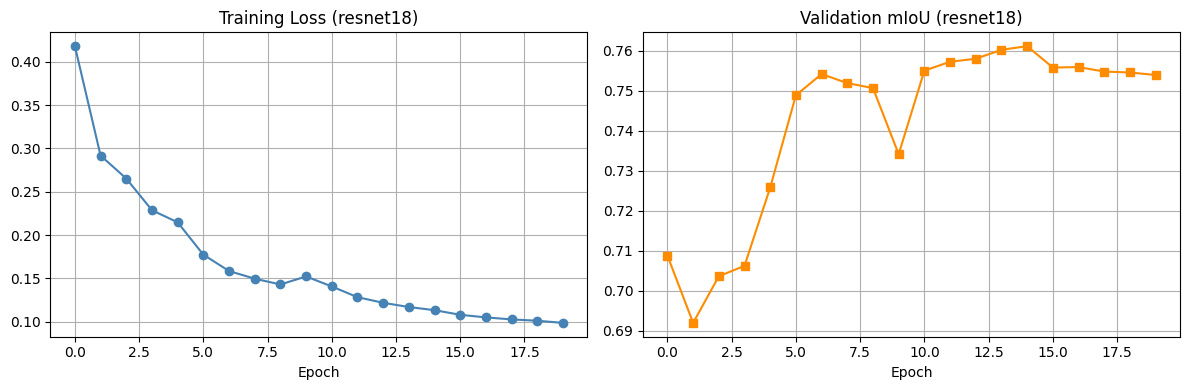

Best mIoU: 0.7612


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, marker='o', color='steelblue')
axes[0].set_title(f'Training Loss ({MODEL_TYPE})'); axes[0].set_xlabel('Epoch'); axes[0].grid(True)
axes[1].plot(val_ious, marker='s', color='darkorange')
axes[1].set_title(f'Validation mIoU ({MODEL_TYPE})'); axes[1].set_xlabel('Epoch'); axes[1].grid(True)
plt.tight_layout(); plt.show()
print(f'Best mIoU: {max(val_ious):.4f}')

## Visualize Predictions

---

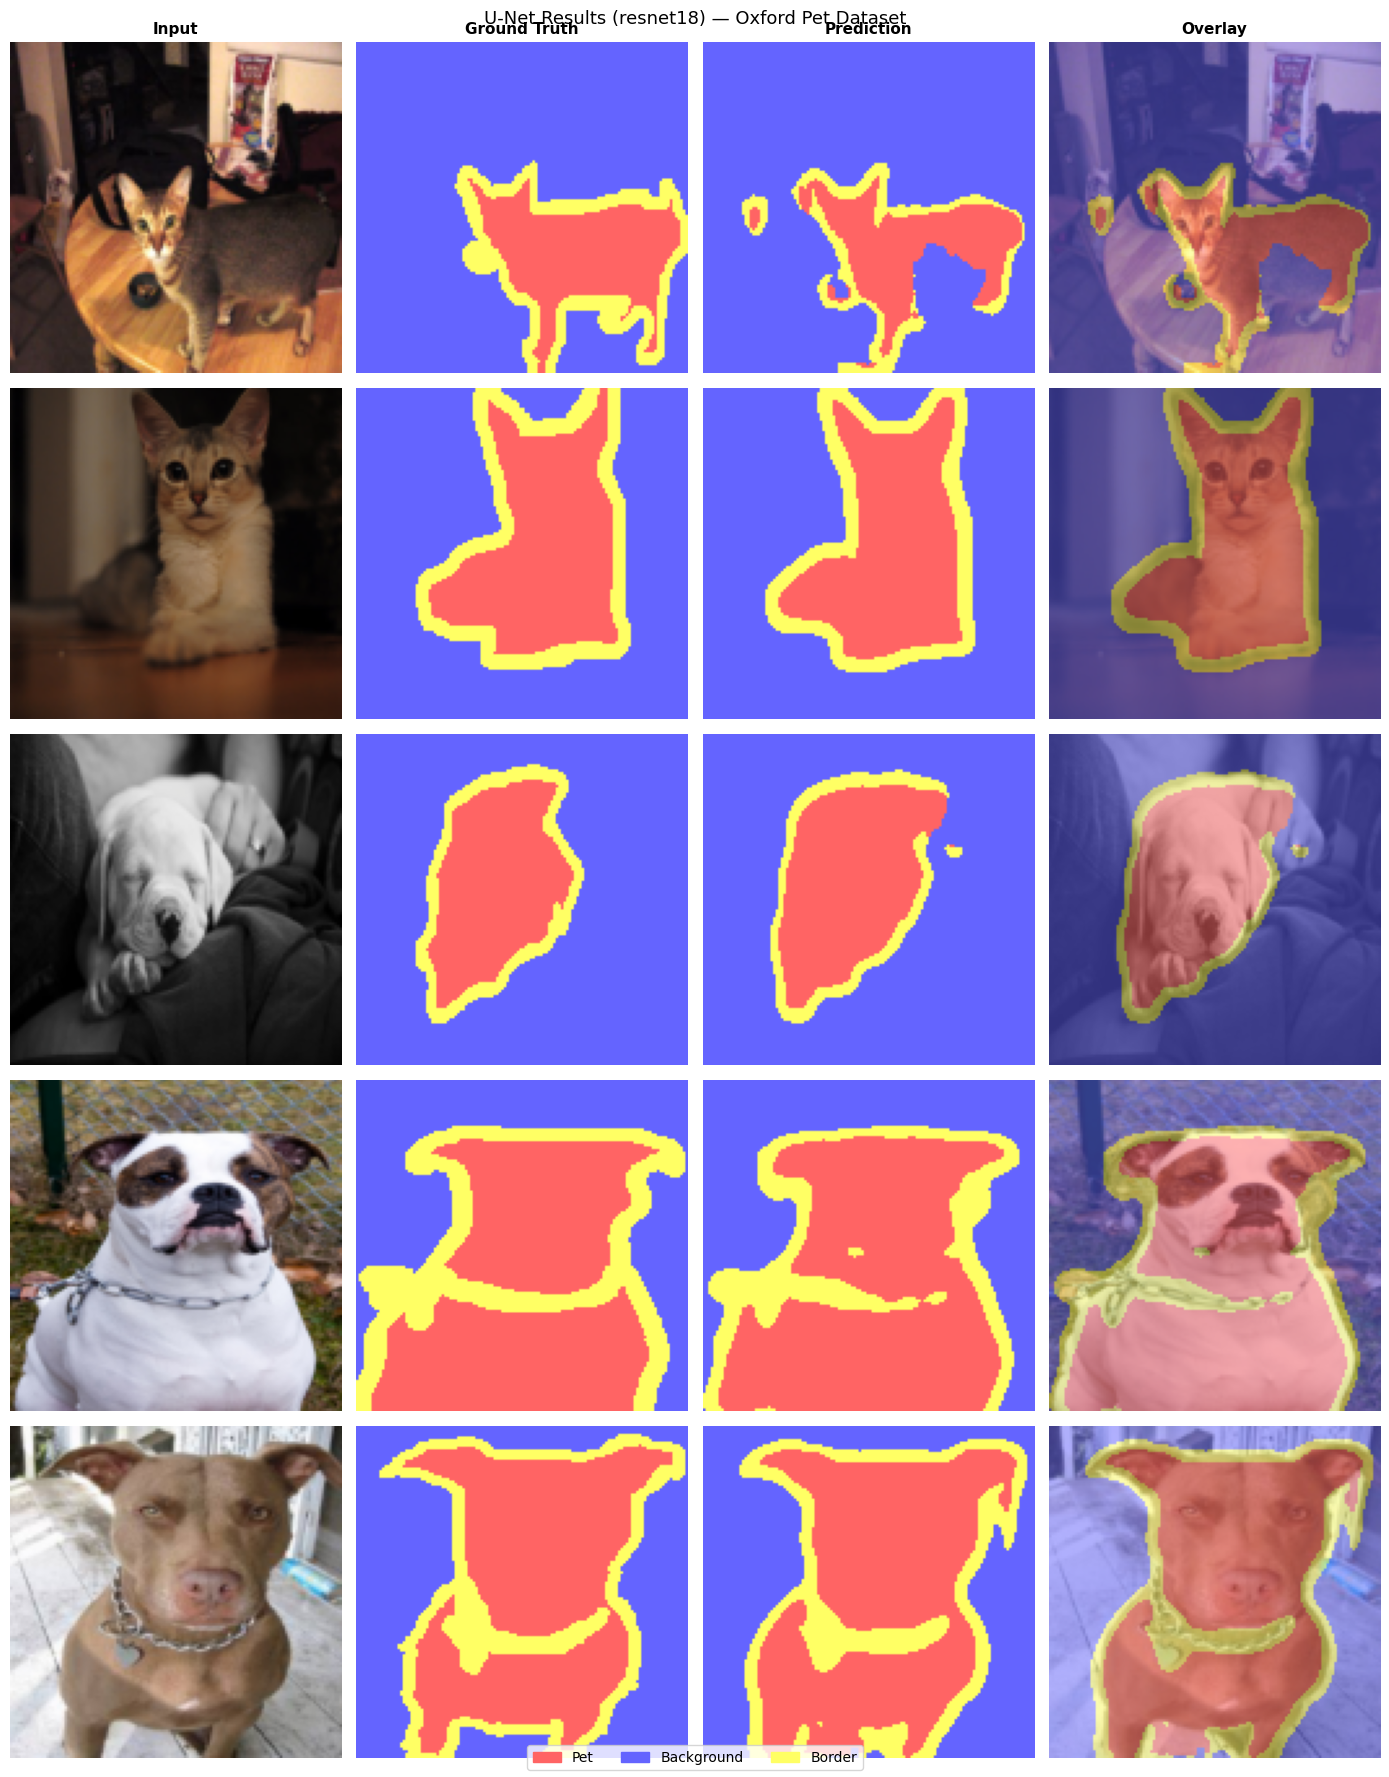

In [12]:
model.load_state_dict(torch.load(save_name, map_location=device))
model.eval()

fig, axes = plt.subplots(5, 4, figsize=(14, 18))
for ax, t in zip(axes[0], ['Input','Ground Truth','Prediction','Overlay']):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row in range(5):
    img, mask = test_data[row*50]
    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device)).argmax(1).squeeze().cpu().numpy()
    img_d  = torch.clamp(img * std + mean, 0, 1).permute(1,2,0).numpy()
    axes[row][0].imshow(img_d)
    axes[row][1].imshow(CLASS_COLORS[mask.numpy()])
    axes[row][2].imshow(CLASS_COLORS[pred_mask])
    axes[row][3].imshow(img_d); axes[row][3].imshow(CLASS_COLORS[pred_mask], alpha=0.5)
    for ax in axes[row]: ax.axis('off')

patches = [plt.Rectangle((0,0),1,1,color=CLASS_COLORS[i]/255) for i in range(3)]
fig.legend(patches, CLASS_NAMES, loc='lower center', ncol=3)
plt.suptitle(f'U-Net Results ({MODEL_TYPE}) — Oxford Pet Dataset', fontsize=13)
plt.tight_layout(); plt.show()


# Exercises

1. **Skip Connections — Do They Matter?**

   Both models use a **pretrained ResNet-18 encoder** (ImageNet weights). The only difference is whether the decoder uses skip connections or not.

   a) Train **two variants** using the `run.py` script:

   ```bash
   # With skip connections (baseline)
   python3 run.py --model unet_resnet18         --dataset oxford_pet --epochs 20 --train

   # Without skip connections (ablation — same ResNet-18 encoder, skip connections removed)
   python3 run.py --model unet_resnet18_no_skip --dataset oxford_pet --epochs 20 --train
   ```

   b) Compare mIoU:

   | Model | Encoder | Skip connections | Val mIoU | Time/epoch |
   |---|---|---|---|---|
   | U-Net + ResNet-18 | ResNet-18 (ImageNet) | ✅ Yes | ? | ? |
   | U-Net + ResNet-18 (no skip) | ResNet-18 (ImageNet) | ❌ No | ? | ? |

   c) Why do skip connections help segmentation more than they would help classification?

   d) Which skip connection level do you think hurts the most when removed — the first (64ch, highest resolution) or the last (512ch, lowest resolution)? Why?
   
---

## Submission

Submit your work to GitHub. Your repository should contain:

### 1. Training Script (`run.py`)

There are **2 models** to train — same ResNet-18 encoder, skip connections differ:

| Model flag | Encoder | Skip connections | Pretrained |
|---|---|---|---|
| `unet_resnet18` | ResNet-18 | ✅ Yes | ✅ ImageNet |
| `unet_resnet18_no_skip` | ResNet-18 | ❌ No | ✅ ImageNet |

```bash
# 1. Baseline — ResNet-18 encoder + skip connections
python3 run.py --model unet_resnet18         --dataset oxford_pet --epochs 20 --train

# 2. Ablation — same ResNet-18 encoder, skip connections REMOVED
python3 run.py --model unet_resnet18_no_skip --dataset oxford_pet --epochs 20 --train

# Evaluate saved model
python3 run.py --model unet_resnet18 --weights unet_resnet18_pet.pt --dataset oxford_pet --evaluate
```

### 2. `README.md`

Your `README.md` must include:

**Commands used** (exact commands you ran)

**Results table:**

| Model | Encoder | Skip connections | Val mIoU | Time/epoch |
|---|---|---|---|---|
| `unet_resnet18` | ResNet-18 (ImageNet) | ✅ | ? | ? |
| `unet_resnet18_no_skip` | ResNet-18 (ImageNet) | ❌ | ? | ? |

**Discussion** (3–5 sentences): How much did skip connections improve mIoU? When would you choose U-Net over Mask R-CNN?


In [14]:
!python3 run.py --model unet_resnet18 --dataset oxford_pet --epochs 20 --train

Using device: cuda
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.44it/s]
Epoch 01 | Loss: 0.4212 | Val mIoU: 0.6515 | Time/epoch: 22.6s
Saved best model -> unet_resnet18_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.88it/s]
Epoch 02 | Loss: 0.2980 | Val mIoU: 0.6922 | Time/epoch: 22.3s
Saved best model -> unet_resnet18_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.11it/s]
Epoch 03 | Loss: 0.2648 | Val mIoU: 0.7211 | Time/epoch: 21.8s
Saved best model -> unet_resnet18_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.18it/s]
Epoch 04 | Loss: 0.2373 | Val mIoU: 0.7298 | Time/epoch: 21.8s
Saved best model -> unet_resnet18_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.02it/s]
Epoch 05 | Loss: 0.2280 | Val mIoU: 0.7017 | Time/epoch: 22.0s
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.02it/s]
Epoch 06 | Loss:

In [15]:
!python3 run.py --model unet_resnet18_no_skip --dataset oxford_pet --epochs 20 --train

Using device: cuda
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.66it/s]
Epoch 01 | Loss: 0.7430 | Val mIoU: 0.4624 | Time/epoch: 20.0s
Saved best model -> unet_resnet18_no_skip_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.78it/s]
Epoch 02 | Loss: 0.4899 | Val mIoU: 0.5196 | Time/epoch: 19.6s
Saved best model -> unet_resnet18_no_skip_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.24it/s]
Epoch 03 | Loss: 0.4340 | Val mIoU: 0.5439 | Time/epoch: 19.2s
Saved best model -> unet_resnet18_no_skip_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:10<00:00, 22.83it/s]
Epoch 04 | Loss: 0.3885 | Val mIoU: 0.5560 | Time/epoch: 19.6s
Saved best model -> unet_resnet18_no_skip_pet.pt
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 24.37it/s]
Epoch 05 | Loss: 0.3645 | Val mIoU: 0.5775 | Time/epoch: 19.5s
Saved best model -> unet_resnet18_no_skip_pet.pt
Evaluate: 100%|█

In [16]:
!python3 run.py --model unet_resnet18 --weights unet_resnet18_pet.pt --dataset oxford_pet --evaluate

Using device: cuda
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.28it/s]
Val mIoU: 0.7570


In [17]:
!python3 run.py --model unet_resnet18_no_skip --weights unet_resnet18_no_skip_pet.pt --dataset oxford_pet --evaluate

Using device: cuda
Evaluate: 100%|███████████████████████████████| 230/230 [00:09<00:00, 23.57it/s]
Val mIoU: 0.6875
